# **Análise Exploratória: Planta IRIS**

10/04/2025

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy import stats
import plotly.express as px

Carga do dataset: usando o arquivo da IRIS já existente no sklearn

In [2]:
data = load_iris()
X = data.data      #atributos de entrada
y = data.target    #classe de saída
feature_names = [name.replace(' (cm)', '') for name in data.feature_names]  #rótulos dos atributos de entrada
target_names = data.target_names #rótulos das classes

Crianda dataframe para facilitar a manipulação dos dados

In [3]:
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['species'] = df['target'].map({i: name for i, name in enumerate(target_names)})
print(df.head())

   sepal length  sepal width  petal length  petal width  target species
0           5.1          3.5           1.4          0.2       0  setosa
1           4.9          3.0           1.4          0.2       0  setosa
2           4.7          3.2           1.3          0.2       0  setosa
3           4.6          3.1           1.5          0.2       0  setosa
4           5.0          3.6           1.4          0.2       0  setosa


# **Inicio da Análise Exploratória dos Dados**

In [4]:
# Configurações para exibição de resultados gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.float_format', lambda x: '%.3f' % x)

**1) Metadados e estrutura do dataset**

In [5]:
print("═"*70)
print("ANÁLISE EXPLORATÓRIA AVANÇADA - DATASET IRIS")
print("═"*70)

print("\n📊 1. METADADOS E ESTRUTURA:")
print(f"• Total de amostras: {len(df)}")
print(f"• Número de features: {len(feature_names)}")
print(f"• Features: {', '.join(feature_names)}")
print(f"• Classes: {', '.join(target_names)}")
print("\n🔍 Amostra dos dados:")
print(df.sample(5))


══════════════════════════════════════════════════════════════════════
ANÁLISE EXPLORATÓRIA AVANÇADA - DATASET IRIS
══════════════════════════════════════════════════════════════════════

📊 1. METADADOS E ESTRUTURA:
• Total de amostras: 150
• Número de features: 4
• Features: sepal length, sepal width, petal length, petal width
• Classes: setosa, versicolor, virginica

🔍 Amostra dos dados:
     sepal length  sepal width  petal length  petal width  target     species
20          5.400        3.400         1.700        0.200       0      setosa
37          4.900        3.600         1.400        0.100       0      setosa
149         5.900        3.000         5.100        1.800       2   virginica
16          5.400        3.900         1.300        0.400       0      setosa
74          6.400        2.900         4.300        1.300       1  versicolor


**2) Análise de Balanceamento das Classes**

Estatística Qui-Quadrado (χ²): mede a discrepância entre as distribuições observadas e esperadas. Quanto maior o valor, maior a discrepância.Valores próximos de zero indicam equilíbrio

Valor-p:

p < 0.05: desbalanceamento estatisticamente significativo

p ≥ 0.05: não há evidência de desbalanceamento significativo


📈 2. BALANCEAMENTO DAS CLASSES:
species
setosa       33.330
versicolor   33.330
virginica    33.330
Name: proportion, dtype: float64

Teste de Chi-quadrado para balanceamento (p-value = 1.0000)
χ²: 0.0


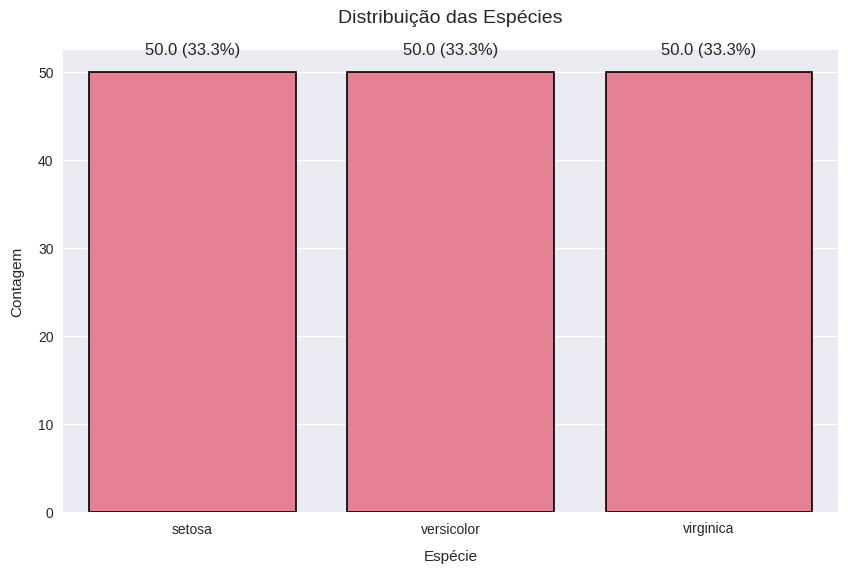

In [6]:
print("\n📈 2. BALANCEAMENTO DAS CLASSES:")
class_dist = df['species'].value_counts(normalize=True) * 100
print(class_dist.round(2))

# Teste de chi-quadrado para balanceamento
chi2, p = stats.chisquare(df['species'].value_counts())
print(f"\nTeste de Chi-quadrado para balanceamento (p-value = {p:.4f})")
print(f"χ²: {chi2}")

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='species', order=target_names,
                  edgecolor='black', linewidth=1.2)
plt.title('Distribuição das Espécies', pad=20, fontsize=14)
plt.xlabel('Espécie', labelpad=10)
plt.ylabel('Contagem', labelpad=10)

# Adicionar porcentagens
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 2,
            f'{height} ({height/len(df)*100:.1f}%)',
            ha='center', fontsize=12)
plt.show()


**3) Estatísticas Descritivas dos Dados**

**Skewness**:  Mede o grau de assimetria da distribuição dos dados em relação à média. Indica se os dados estão mais concentrados à esquerda ou à direita da distribuição

Interpretação:

Skewness = 0: Distribuição simétrica (ex.: distribuição normal)

Skewness > 0: Assimetria positiva (cauda alongada à direita)

Skewness < 0: Assimetria negativa (cauda alongada à esquerda)

**Kurtosis** : Mede o "achatamento" ou "pico" da distribuição. A concentração de dados em torno da média versus nas caudas.

Interpretação (kurtosis normalizado):

Kurtosis = 0: Mesma curtose que a distribuição normal

Kurtosis > 0: Distribuição mais "pontiaguda" com caudas pesadas

Mais dados próximos da média e nos extremos.
Maior probabilidade de outliers

Kurtosis < 0: Distribuição mais "achatada" (platicúrtica)

Dados mais uniformemente distribuídos.
Menos concentração em torno da média


In [7]:
print("\n📉 3. ESTATÍSTICAS DESCRITIVAS DOS DADOS:")
desc_stats = df[feature_names].describe().T
desc_stats['skewness'] = df[feature_names].skew()
desc_stats['kurtosis'] = df[feature_names].kurtosis()
desc_stats['CV (%)'] = (df[feature_names].std() / df[feature_names].mean()) * 100
print(desc_stats.round(3))



📉 3. ESTATÍSTICAS DESCRITIVAS DOS DADOS:
               count  mean   std   min   25%   50%   75%   max  skewness  \
sepal length 150.000 5.843 0.828 4.300 5.100 5.800 6.400 7.900     0.315   
sepal width  150.000 3.057 0.436 2.000 2.800 3.000 3.300 4.400     0.319   
petal length 150.000 3.758 1.765 1.000 1.600 4.350 5.100 6.900    -0.275   
petal width  150.000 1.199 0.762 0.100 0.300 1.300 1.800 2.500    -0.103   

              kurtosis  CV (%)  
sepal length    -0.552  14.171  
sepal width      0.228  14.256  
petal length    -1.402  46.974  
petal width     -1.341  63.555  


**4) Análise de Distribuição das features**


🎻 4. DISTRIBUIÇÃO DAS FEATURES :


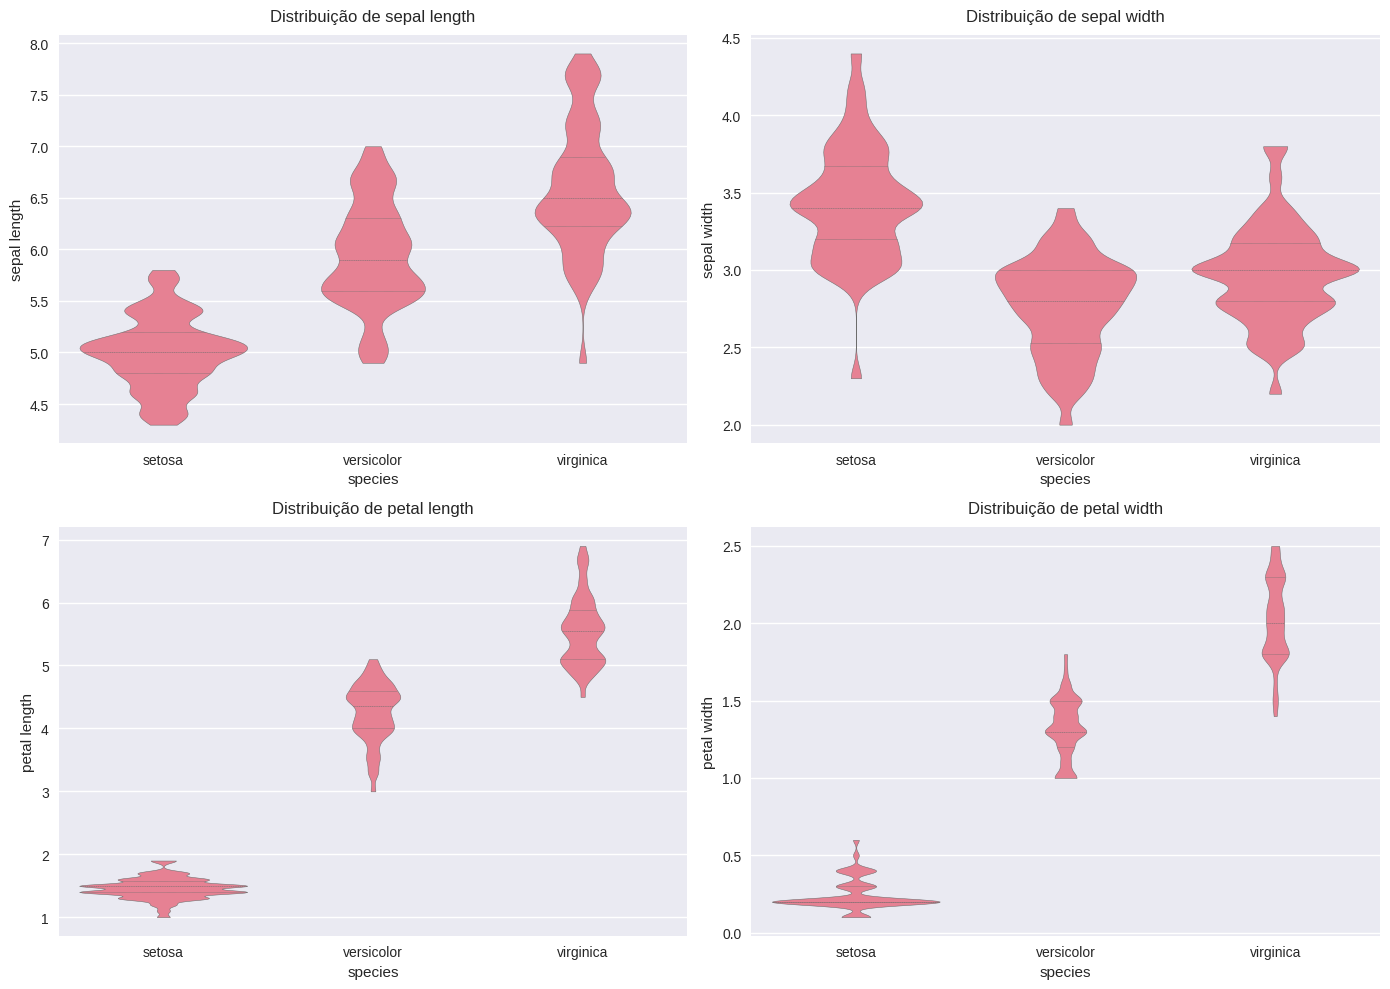

In [8]:
print("\n🎻 4. DISTRIBUIÇÃO DAS FEATURES :")
plt.figure(figsize=(14, 10))
for i, feature in enumerate(feature_names):
    plt.subplot(2, 2, i+1)
    sns.violinplot(data=df, x='species', y=feature,
                  inner='quartile', cut=0, bw_method=0.2)
    plt.title(f'Distribuição de {feature}', pad=10)
plt.tight_layout()
plt.show()

**5) Correlação entre as features**


🔗 5. MATRIZ DE CORRELAÇÃO E P-VALUES:


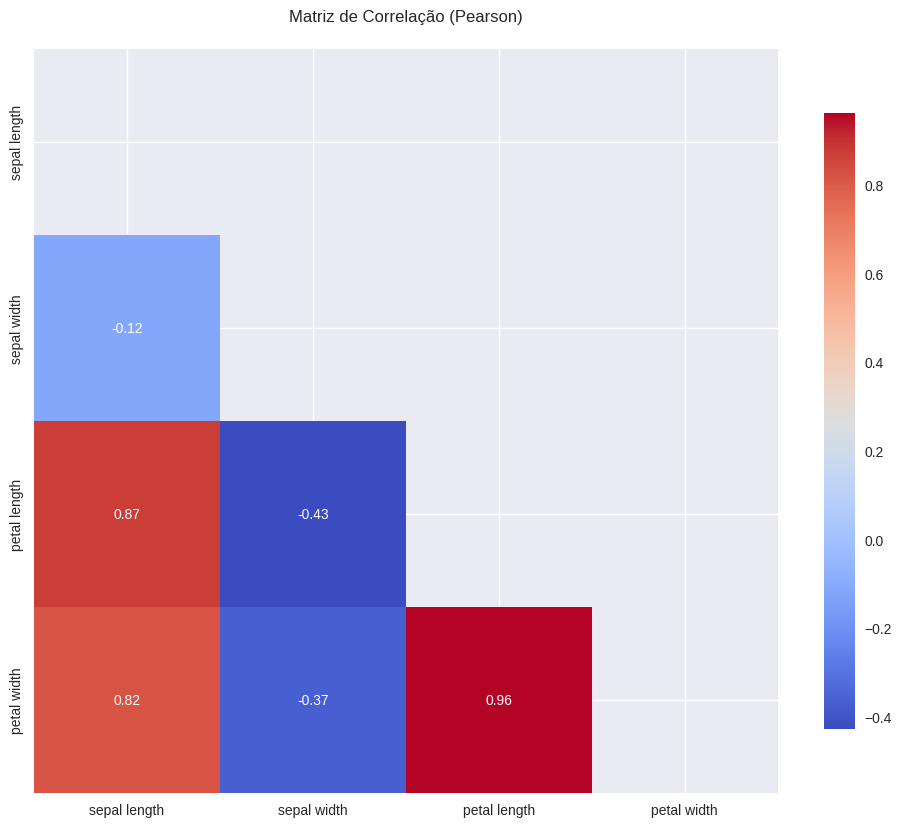


Matriz de p-values:
              sepal length  sepal width  petal length  petal width
sepal length         0.000        0.152         0.000        0.000
sepal width          0.152        0.000         0.000        0.000
petal length         0.000        0.000         0.000        0.000
petal width          0.000        0.000         0.000        0.000


In [9]:
# Correlação com Análise de Significância
print("\n🔗 5. MATRIZ DE CORRELAÇÃO E P-VALUES:")
corr_matrix = df[feature_names].corr(method='pearson')

# Calcular p-values
p_values = np.zeros_like(corr_matrix)
for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        if i != j:
            _, p_values[i, j] = stats.pearsonr(df[feature_names[i]], df[feature_names[j]])

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            mask=np.triu(np.ones_like(corr_matrix, dtype=bool)),
            cbar_kws={"shrink": .8}, square=True)
plt.title('Matriz de Correlação (Pearson)', pad=20)
plt.show()

print("\nMatriz de p-values:")
print(pd.DataFrame(p_values, columns=feature_names, index=feature_names).round(4))

**6) Análise de Outiliers**


📌 6. ANÁLISE DE OUTLIERS:


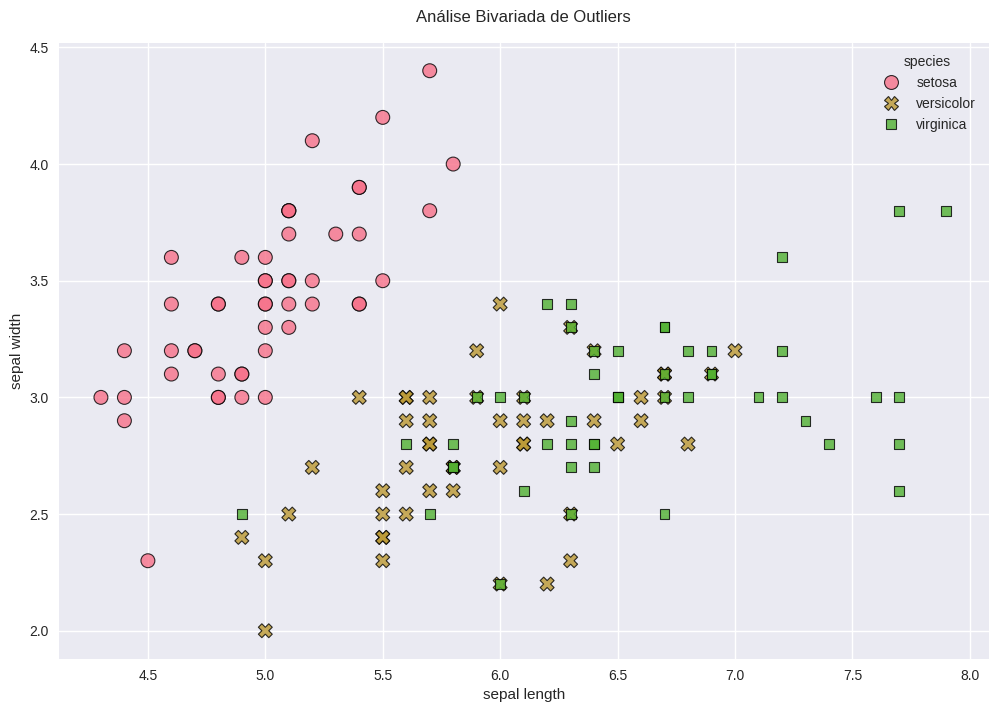

In [10]:
# 6. Análise de Outliers Multivariada
print("\n📌 6. ANÁLISE DE OUTLIERS:")
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='sepal length', y='sepal width',
               hue='species', style='species', s=100,
               edgecolor='black', alpha=0.8)
plt.title('Análise Bivariada de Outliers', pad=15)
plt.show()

**7) Análise de Dimensionabilidade**

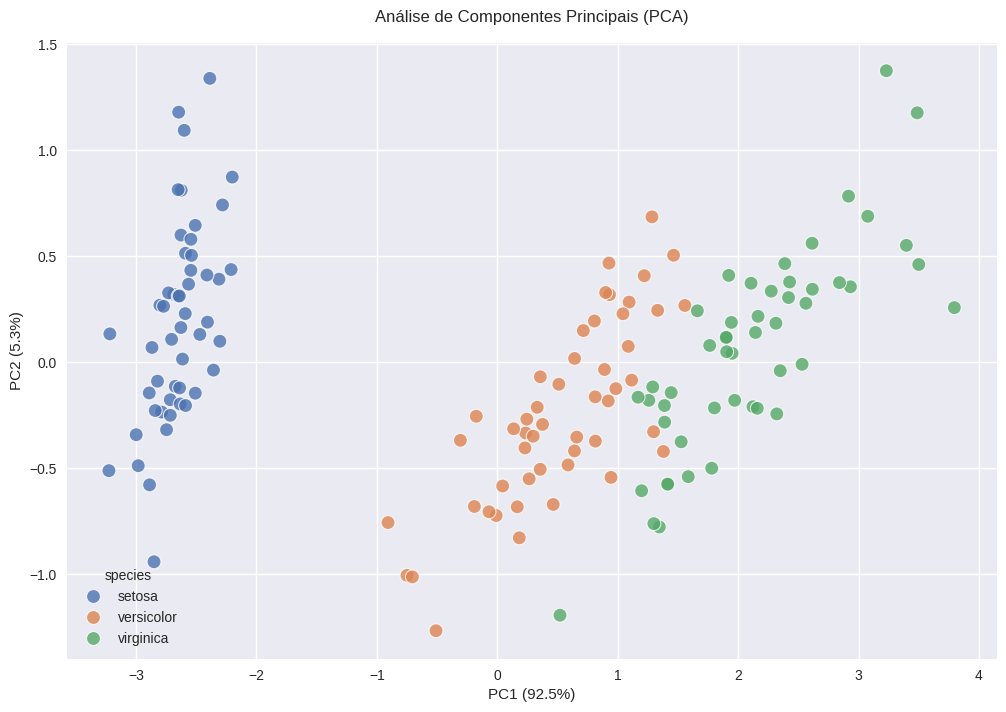

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df[feature_names])
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['species'] = df['species']

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='species',
               palette='deep', s=100, alpha=0.8)
plt.title('Análise de Componentes Principais (PCA)', pad=15)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.show()


🌐 8. DISTRIBUIÇÃO CONJUNTA (PAIRGRID):


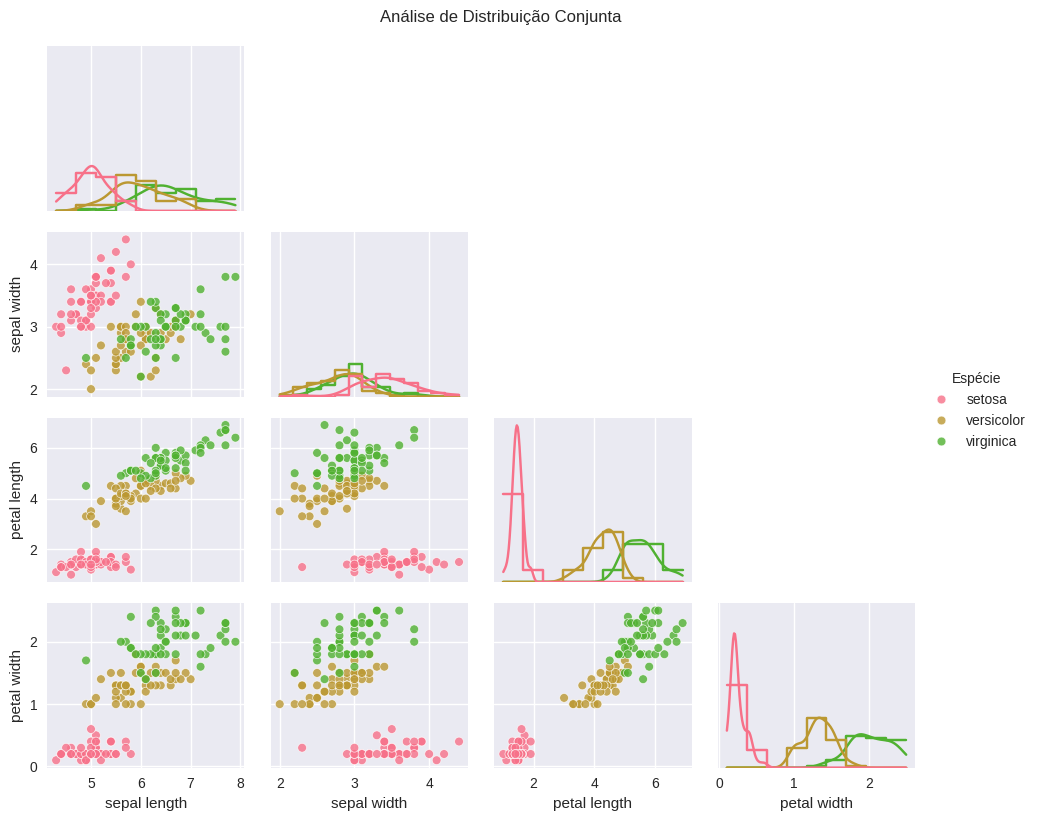

In [12]:
# 8. Análise de Distribuição Conjunta
print("\n🌐 8. DISTRIBUIÇÃO CONJUNTA (PAIRGRID):")
g = sns.PairGrid(df, vars=feature_names, hue='species',
                corner=True, height=2, aspect=1.2)
g.map_lower(sns.scatterplot, s=40, alpha=0.8, edgecolor='w')
g.map_diag(sns.histplot, kde=True, element='step', fill=False)
g.add_legend(title='Espécie')
plt.suptitle('Análise de Distribuição Conjunta', y=1.02)
plt.show()

In [13]:
# 9. Teste ANOVA entre classes
print("\n🔬 9. TESTE ANOVA ENTRE CLASSES:")
for feature in feature_names:
    groups = [df[df['species'] == species][feature] for species in target_names]
    f_val, p_val = stats.f_oneway(*groups)
    print(f"{feature:15s} → F-value: {f_val:7.3f}, p-value: {p_val:.5f}")


🔬 9. TESTE ANOVA ENTRE CLASSES:
sepal length    → F-value: 119.265, p-value: 0.00000
sepal width     → F-value:  49.160, p-value: 0.00000
petal length    → F-value: 1180.161, p-value: 0.00000
petal width     → F-value: 960.007, p-value: 0.00000



📶 10. ANÁLISE DE DISTRIBUIÇÃO ACUMULADA:


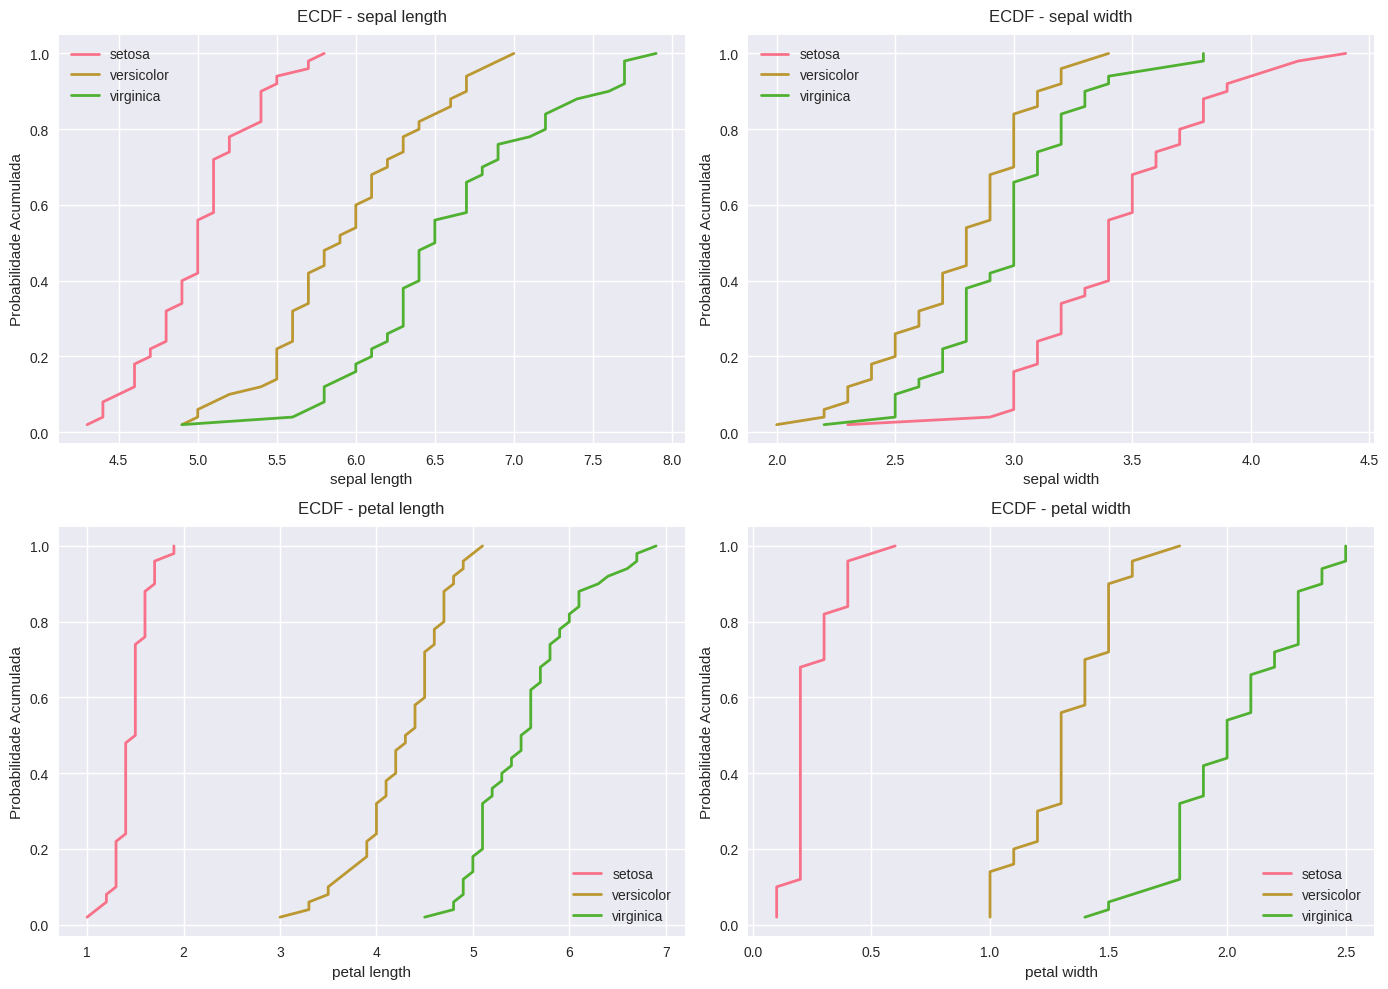

In [14]:
# 10. Análise de Densidade Cumulativa (ECDF)
print("\n📶 10. ANÁLISE DE DISTRIBUIÇÃO ACUMULADA:")
plt.figure(figsize=(14, 10))
for i, feature in enumerate(feature_names):
    plt.subplot(2, 2, i+1)
    for species in target_names:
        x = np.sort(df[df['species'] == species][feature])
        y = np.arange(1, len(x)+1)/len(x)
        plt.plot(x, y, label=species, lw=2)
    plt.title(f'ECDF - {feature}', pad=10)
    plt.xlabel(feature)
    plt.ylabel('Probabilidade Acumulada')
    plt.legend()
plt.tight_layout()
plt.show()